In [1]:
import numpy as Np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import seaborn as sns
df = sns.load_dataset("mpg")

In [2]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [3]:
df.drop('name',axis=1,inplace=True)

In [4]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [6]:
df['horsepower'] =df['horsepower'].fillna(df['horsepower'].median())

In [7]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [9]:
df['origin'] = df['origin'].map({'usa':1,'japan':2,'europe':3})

In [11]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
dtype: object

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x = df.drop('mpg',axis=1)
y = df['mpg']

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=1)

In [15]:
x_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
350,4,105.0,63.0,2215,14.9,81,1
59,4,97.0,54.0,2254,23.5,72,3
120,4,121.0,112.0,2868,15.5,73,3
12,8,400.0,150.0,3761,9.5,70,1
349,4,91.0,68.0,1985,16.0,81,2
...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1
255,4,140.0,88.0,2720,15.4,78,1
72,8,304.0,150.0,3892,12.5,72,1
235,4,97.0,75.0,2265,18.2,77,2


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

In [18]:
model.fit(x_train,y_train)

LinearRegression()

In [19]:
model.coef_

array([-0.31761423,  0.02623748, -0.01827076, -0.00748775,  0.05040673,
        0.84709514,  1.51909584])

In [20]:
model.intercept_

np.float64(-23.08538074231676)

In [23]:
for i , col_name in enumerate(x_train.columns):
    print(f"the coefficient for {col_name}is {model.coef_[i]}")

the coefficient for cylindersis -0.317614230279928
the coefficient for displacementis 0.026237482599078973
the coefficient for horsepoweris -0.01827076491312446
the coefficient for weightis -0.007487750398361911
the coefficient for accelerationis 0.0504067346197149
the coefficient for model_yearis 0.8470951427061373
the coefficient for originis 1.519095838797505


In [24]:
y_pred = model.predict(x_test)

In [25]:
from sklearn.metrics import mean_squared_error,r2_score

In [26]:
mean_squared_error(y_test,y_pred)

9.658732193155874

In [29]:
r2_score(y_test,y_pred)

0.8348001123742285

In [30]:
#ridge regression
from sklearn.linear_model import Ridge

In [33]:
ridge = Ridge(alpha=0.1)

In [34]:
ridge.fit(x_train,y_train)

Ridge(alpha=0.1)

In [35]:
ridge.coef_

array([-0.31700321,  0.02621325, -0.01826325, -0.00748733,  0.05036897,
        0.84700629,  1.51745283])

In [36]:
for i , col_name in enumerate(x_train.columns):
    print(f"the coefficient for {col_name}is {ridge.coef_[i]}")

the coefficient for cylindersis -0.3170032101006763
the coefficient for displacementis 0.0262132497579838
the coefficient for horsepoweris -0.018263252481448618
the coefficient for weightis -0.007487326050213165
the coefficient for accelerationis 0.05036896947443228
the coefficient for model_yearis 0.8470062938903182
the coefficient for originis 1.5174528285653937


In [37]:
y_pred = ridge.predict(x_test)

In [38]:
r2_score(y_test,y_pred)

0.8348084889168356

In [39]:
from sklearn.linear_model import Lasso

In [40]:
lasso = Lasso(alpha=0.5)

In [41]:
lasso.fit(x_train,y_train)

Lasso(alpha=0.5)

In [44]:
for i , col_name in enumerate(x_train.columns):
    print(f"the coefficient for {col_name}is {lasso.coef_[i]}")

the coefficient for cylindersis -0.0
the coefficient for displacementis 0.0062081988883003845
the coefficient for horsepoweris -0.011058382987169572
the coefficient for weightis -0.00698267316802309
the coefficient for accelerationis 0.0
the coefficient for model_yearis 0.744654952003819
the coefficient for originis 0.0


In [45]:
y_pred = lasso.predict(x_test)

In [46]:
r2_score(y_test,y_pred)

0.8277934716635555

In [47]:
#elastic net
from sklearn.linear_model import ElasticNet

In [54]:
elastic = ElasticNet(alpha=1,l1_ratio=0.5)

In [55]:
elastic.fit(x_train,y_train)

ElasticNet(alpha=1)

In [56]:
elastic.coef_

array([-0.        ,  0.00588887, -0.01240387, -0.00693455,  0.        ,
        0.71331507,  0.        ])

In [57]:
for i , col_name in enumerate(x_train.columns):
    print(f"the coefficient for {col_name}is {elastic.coef_[i]}")

the coefficient for cylindersis -0.0
the coefficient for displacementis 0.005888869953667572
the coefficient for horsepoweris -0.0124038749335701
the coefficient for weightis -0.006934550516257633
the coefficient for accelerationis 0.0
the coefficient for model_yearis 0.7133150744603874
the coefficient for originis 0.0


In [58]:
y_pred = elastic.predict(x_test)

In [59]:
r2_score(y_test,y_pred)

0.8284840073256803

In [60]:
from sklearn.linear_model import LassoCV
lasoocv = LassoCV()

In [61]:
lasoocv.fit(x_train,y_train)

LassoCV()

In [62]:
y_pred = lasoocv.predict(x_test)

In [63]:
r2_score(y_test,y_pred)

0.808280598384475

In [64]:
from sklearn.linear_model import RidgeCV
rigecv = RidgeCV()

rigecv.fit(x_train,y_train)
y_pred = rigecv.predict(x_test)
r2_score(y_test,y_pred)

0.8354145247345831

In [65]:
rigecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': None,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

In [66]:
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV()

elasticcv.fit(x_train,y_train)
y_pred = elasticcv.predict(x_test)
r2_score(y_test,y_pred)

0.792863401804916

Generated synthetic regression data and trained Ridge, Lasso, and ElasticNet models with alpha=1.0. Coefficients comparison plot saved as 'coefficients_comparison.png'.


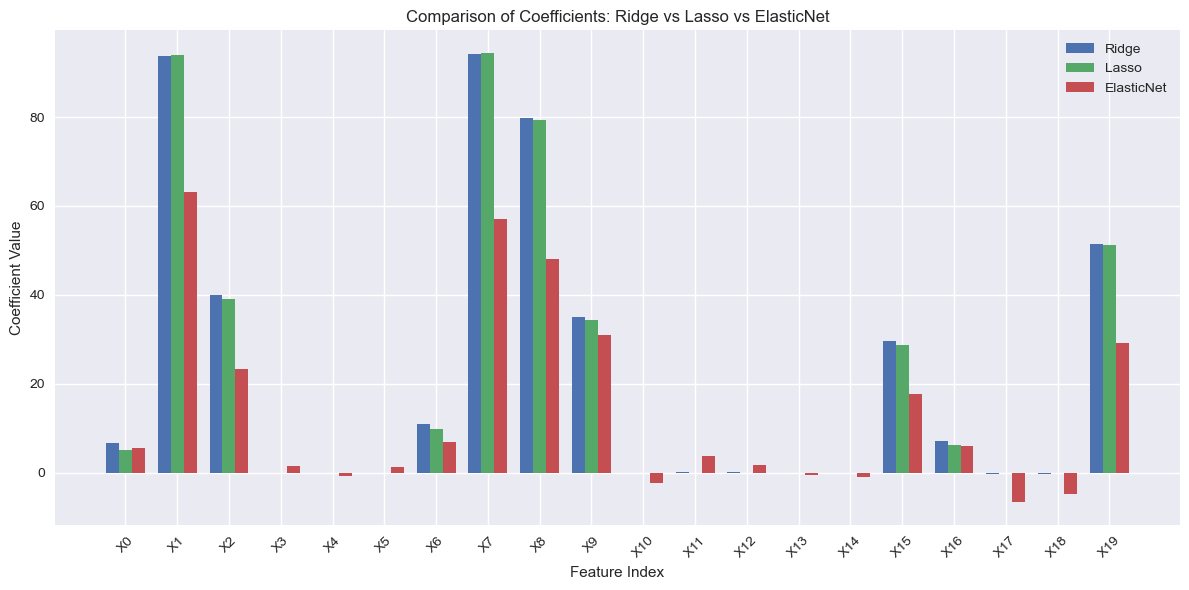

In [2]:
# Generating synthetic regression data and comparing Ridge, Lasso, and ElasticNet coefficients
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic regression data
X, y = make_regression(n_samples=100, n_features=20, noise=0.1, random_state=42)

# Initialize models with alpha=1.0
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Fit models
ridge.fit(X, y)
lasso.fit(X, y)
elastic.fit(X, y)

# Collect coefficients
coefficients = pd.DataFrame({
    'Feature': [f'X{i}' for i in range(X.shape[1])],
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

# Plot coefficients
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))
index = np.arange(X.shape[1])
bar_width = 0.25

plt.bar(index, coefficients['Ridge'], bar_width, label='Ridge')
plt.bar(index + bar_width, coefficients['Lasso'], bar_width, label='Lasso')
plt.bar(index + 2 * bar_width, coefficients['ElasticNet'], bar_width, label='ElasticNet')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: Ridge vs Lasso vs ElasticNet')
plt.xticks(index + bar_width, coefficients['Feature'], rotation=45)
plt.legend()
plt.tight_layout()

# Save plot

print("Generated synthetic regression data and trained Ridge, Lasso, and ElasticNet models with alpha=1.0. Coefficients comparison plot saved as 'coefficients_comparison.png'.")

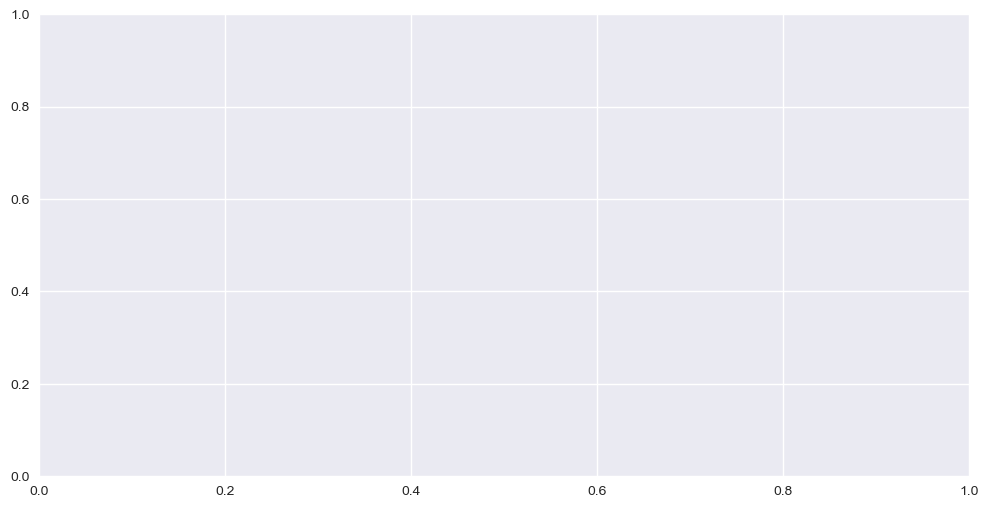

In [6]:
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))
index = np.arange(X.shape[1])
bar_width = 0.25

In [5]:
X.shape[1]

20

In [7]:
from sklearn.datasets import make_classification

In [14]:
from sklearn.linear_model import LogisticRegression

In [9]:
x,y =make_classification(n_samples=1000, n_features=10,n_redundant=5,n_informative=5,n_classes=2,random_state=1)

In [10]:
x

array([[ 2.56999479, -0.13019997,  3.16075093, ..., -1.93094078,
         3.26130366,  2.05692145],
       [ 0.34129317,  2.51321418, -0.80416572, ...,  6.24734437,
        -1.92769365,  2.9503149 ],
       [ 2.27539972,  3.36561455,  0.17164362, ...,  2.74693781,
         0.13492444,  2.00339547],
       ...,
       [ 0.5234359 ,  1.90466429,  0.93243365, ...,  1.53945231,
         1.90646166,  1.99458587],
       [ 1.33747921,  3.25859684,  0.78792366, ...,  5.18788314,
        -0.82071083,  3.51411431],
       [-0.98534299,  0.83919047,  2.5820803 , ...,  3.04705685,
         0.66885641,  3.32838496]])

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.30, random_state=1)

In [15]:
model =LogisticRegression()

In [16]:
model.fit(x_train,y_train)

LogisticRegression()

In [17]:
y_pred =model.predict(x_test)